# CFN Graph — Visualise & Test
Explore `data/cfn_graph.pkl`: stats, degree distribution, per-resource subgraphs, and RAG smoke tests.

In [1]:
import pickle, pathlib, collections, random
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display

# Optional — only needed for interactive widget cell
try:
    import ipywidgets as widgets
    from IPython.display import display as wdisplay
    HAS_WIDGETS = True
except ImportError:
    HAS_WIDGETS = False
    print('ipywidgets not installed — widget cell will be skipped.')


In [3]:
GRAPH_PATH = pathlib.Path('./cfn-schema/cfn_graph.pkl')
assert GRAPH_PATH.exists(), f'Not found: {GRAPH_PATH}'

with open(GRAPH_PATH, 'rb') as f:
    G = pickle.load(f)

# Handle both (G,) and (G, embedder) pickle formats
if isinstance(G, tuple):
    G = G[0]

print(f'Loaded graph: {G.number_of_nodes():,} nodes  {G.number_of_edges():,} edges')


Loaded graph: 46,820 nodes  45,251 edges


## 1 · Graph Statistics

In [4]:
ntypes = collections.Counter(d.get('ntype','?') for _, d in G.nodes(data=True))
etypes = collections.Counter(d.get('etype','?') for _, _, d in G.edges(data=True))

print('=== Node types ===')
for k, v in ntypes.most_common(): print(f'  {k:<20} {v:>7,}')

print('\n=== Edge types ===')
for k, v in etypes.most_common(): print(f'  {k:<25} {v:>7,}')

resources = [n for n, d in G.nodes(data=True) if d.get('ntype')=='ResourceType']
print(f'\nTop 10 resource types by out-degree (most properties):')
deg = sorted(resources, key=lambda n: G.out_degree(n), reverse=True)[:10]
for r in deg:
    print(f'  {r:<55} {G.out_degree(r):>4} edges out')


=== Node types ===
  Property              36,733
  PropertyType           8,519
  ResourceType           1,568

=== Edge types ===
  HAS_PROPERTY               36,733
  HAS_PROPERTY_TYPE           8,518

Top 10 resource types by out-degree (most properties):
  AWS::QuickSight::Dashboard                               589 edges out
  AWS::QuickSight::Analysis                                569 edges out
  AWS::QuickSight::Template                                528 edges out
  AWS::MediaLive::Channel                                  205 edges out
  AWS::Lex::Bot                                            128 edges out
  AWS::QuickSight::DataSet                                 107 edges out
  AWS::WAFv2::WebACL                                       102 edges out
  AWS::S3::Bucket                                           92 edges out
  AWS::RDS::DBInstance                                      88 edges out
  AWS::KinesisFirehose::DeliveryStream                      84 edges out


## 2 · Resources by AWS Service

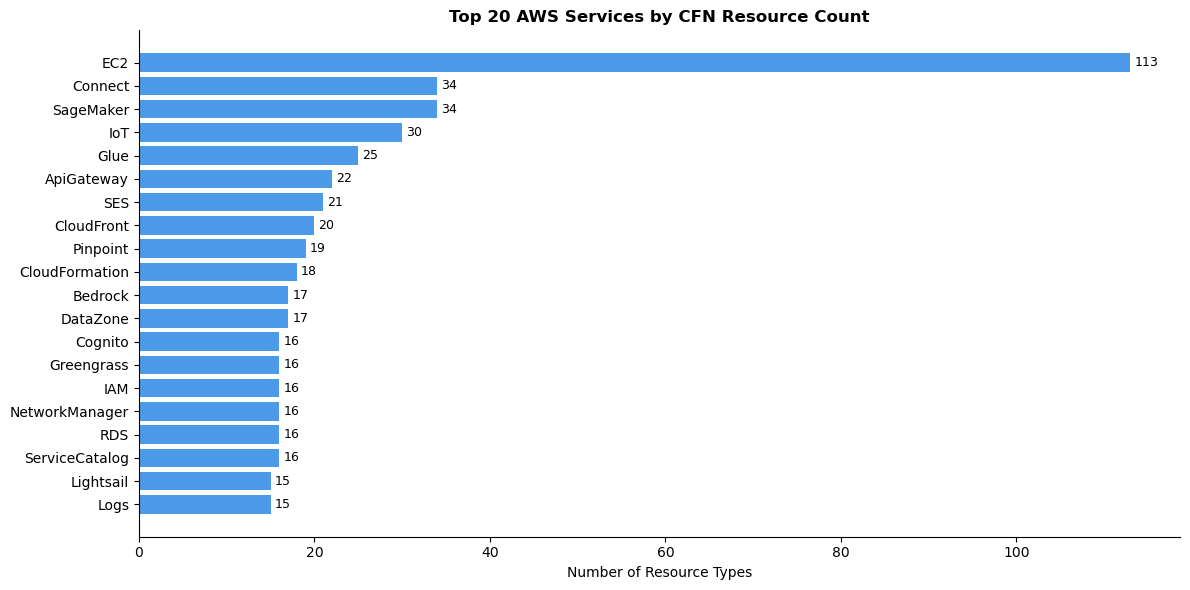

Saved → ./cfn-schema/cfn_services.png


In [6]:
service_counts = collections.Counter()
for n in resources:
    parts = n.split('::')
    if len(parts) >= 2:
        service_counts[parts[1]] += 1

top_services = service_counts.most_common(20)
services, counts = zip(*top_services)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(services[::-1], counts[::-1], color='#4C9BE8')
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_xlabel('Number of Resource Types')
ax.set_title('Top 20 AWS Services by CFN Resource Count', fontweight='bold')
ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('./cfn-schema/cfn_services.png', dpi=130)
plt.show()
print('Saved → ./cfn-schema/cfn_services.png')


## 3 · Property-Count Distribution

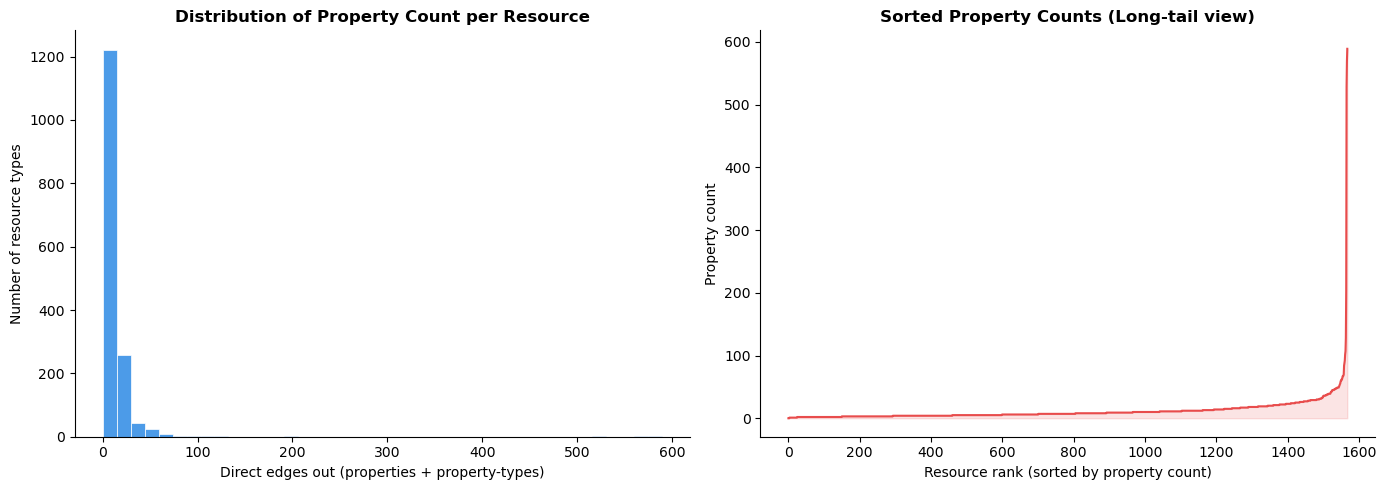

,property_count
count,1568.000000
mean,12.050383
std,27.142549
min,0.000000
25%,4.000000
50%,7.000000
75%,13.000000
max,589.000000


In [7]:
prop_counts = [G.out_degree(n) for n in resources]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(prop_counts, bins=40, color='#4C9BE8', edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Direct edges out (properties + property-types)')
axes[0].set_ylabel('Number of resource types')
axes[0].set_title('Distribution of Property Count per Resource', fontweight='bold')
axes[0].spines[['top','right']].set_visible(False)

# Box + swarm substitute: sorted line
sorted_counts = sorted(prop_counts)
axes[1].plot(sorted_counts, color='#E84C4C', linewidth=1.5)
axes[1].fill_between(range(len(sorted_counts)), sorted_counts, alpha=0.15, color='#E84C4C')
axes[1].set_xlabel('Resource rank (sorted by property count)')
axes[1].set_ylabel('Property count')
axes[1].set_title('Sorted Property Counts (Long-tail view)', fontweight='bold')
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('./cfn-schema/cfn_degree_dist.png', dpi=130)
plt.show()

df_stats = pd.Series(prop_counts).describe().rename('property_count')
display(df_stats.to_frame())


## 4 · Subgraph Visualisation
Visualise the 2-hop neighbourhood of any resource type.

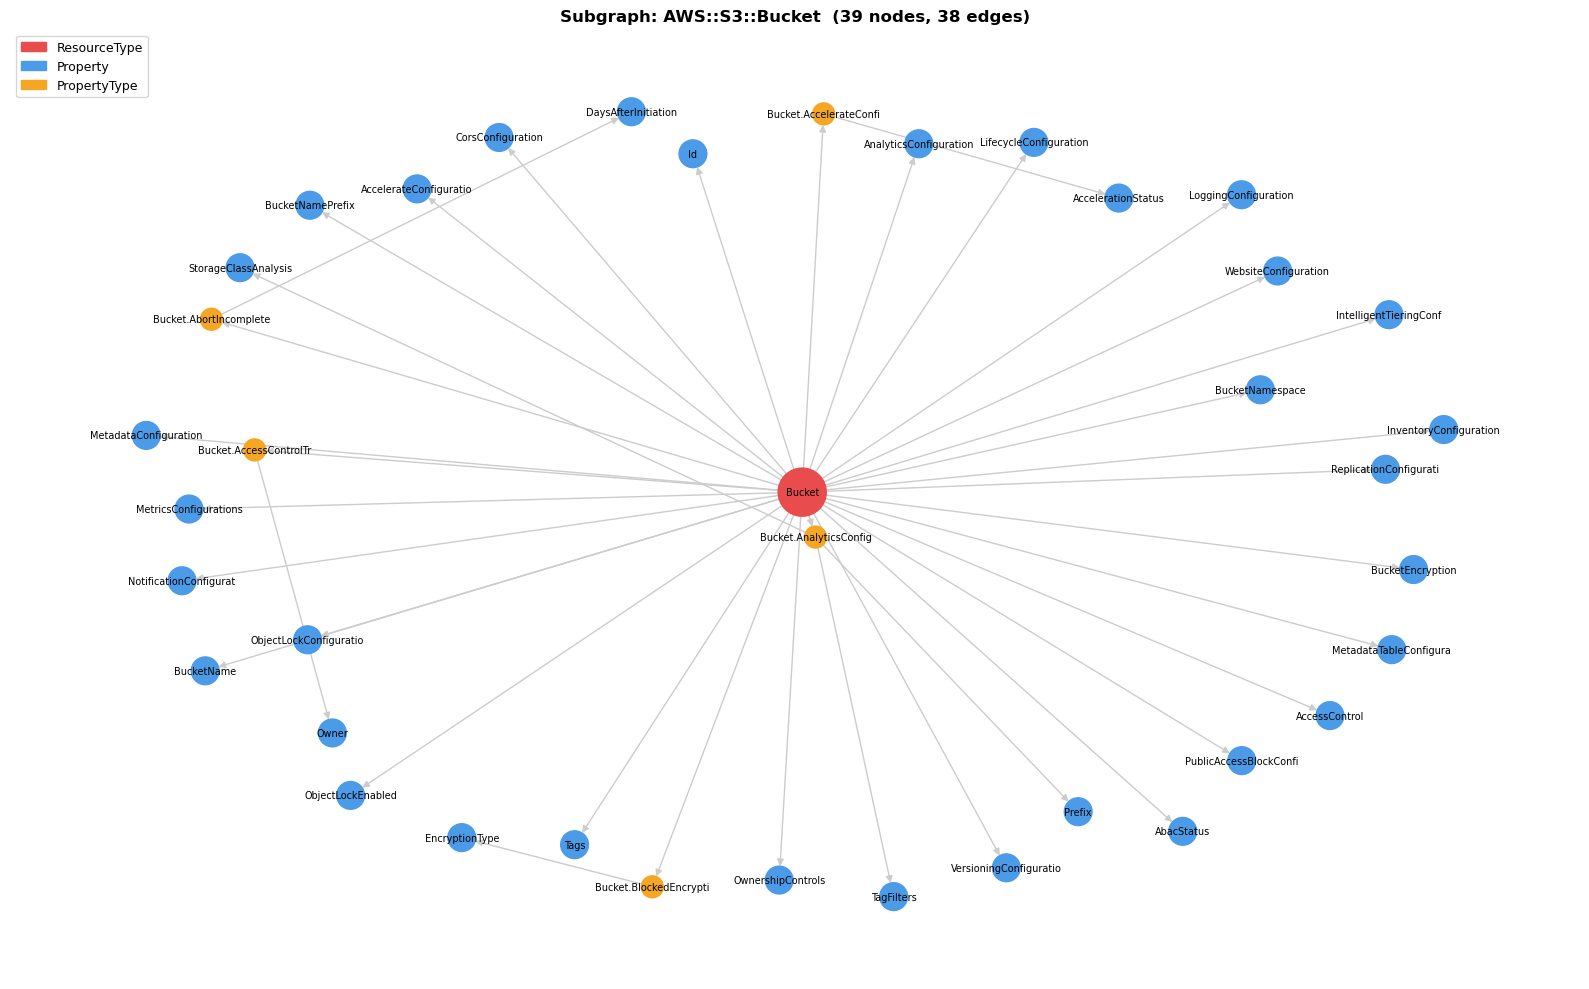

Saved → ./cfn-schema/subgraph_AWS_S3_Bucket.png


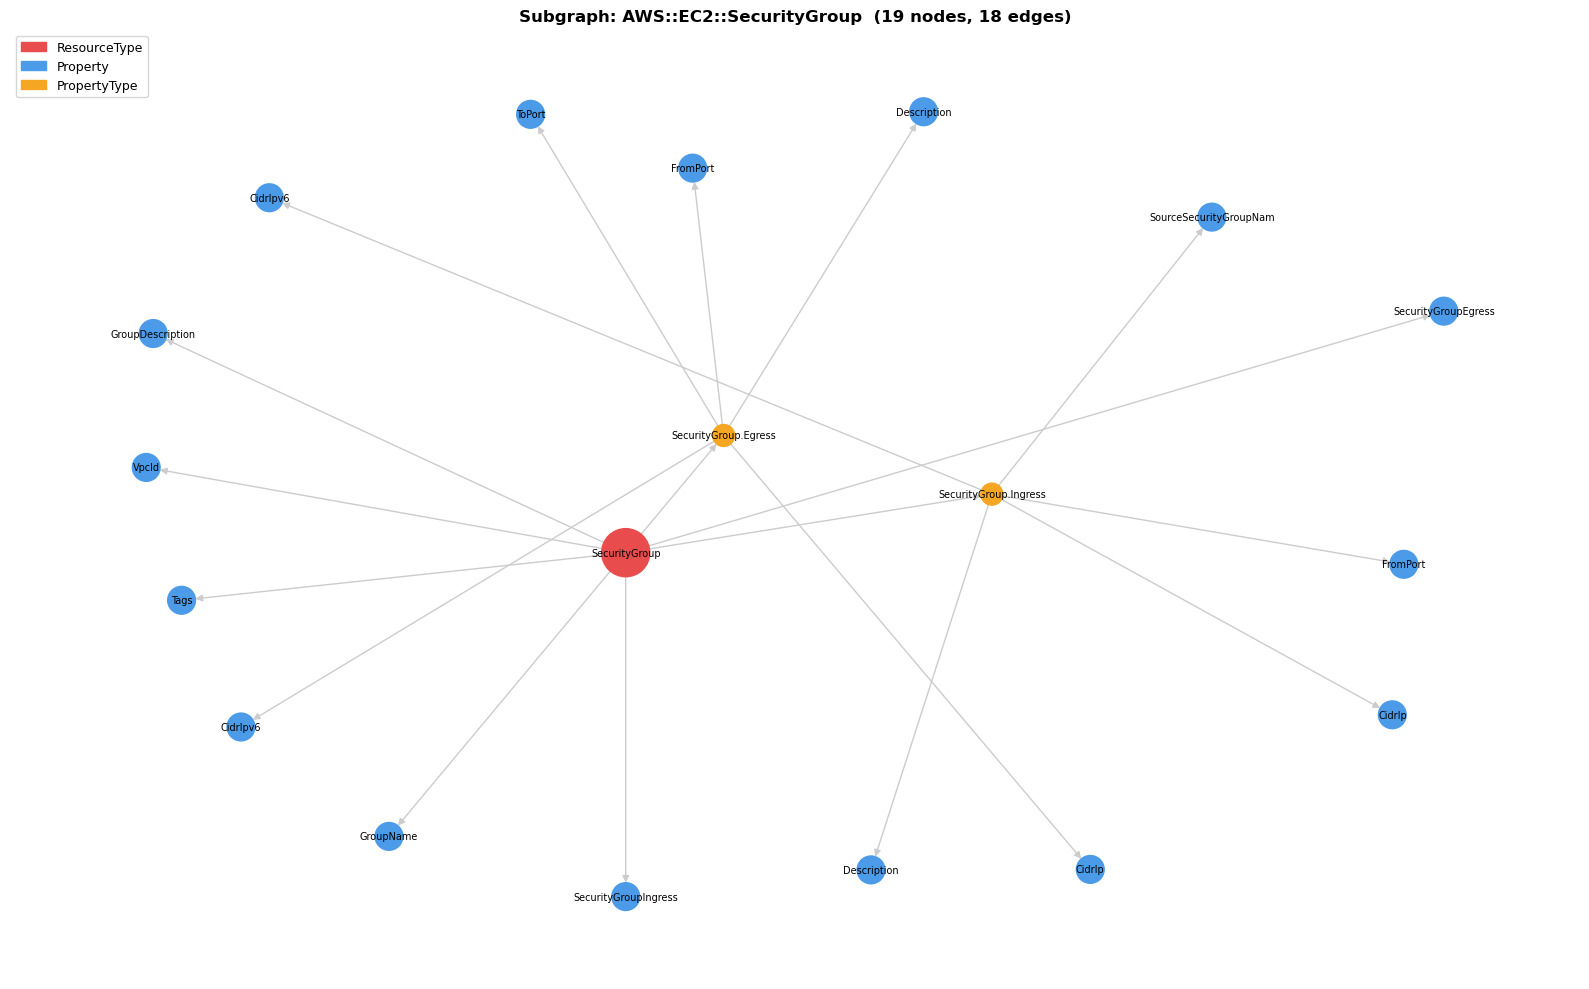

Saved → ./cfn-schema/subgraph_AWS_EC2_SecurityGroup.png


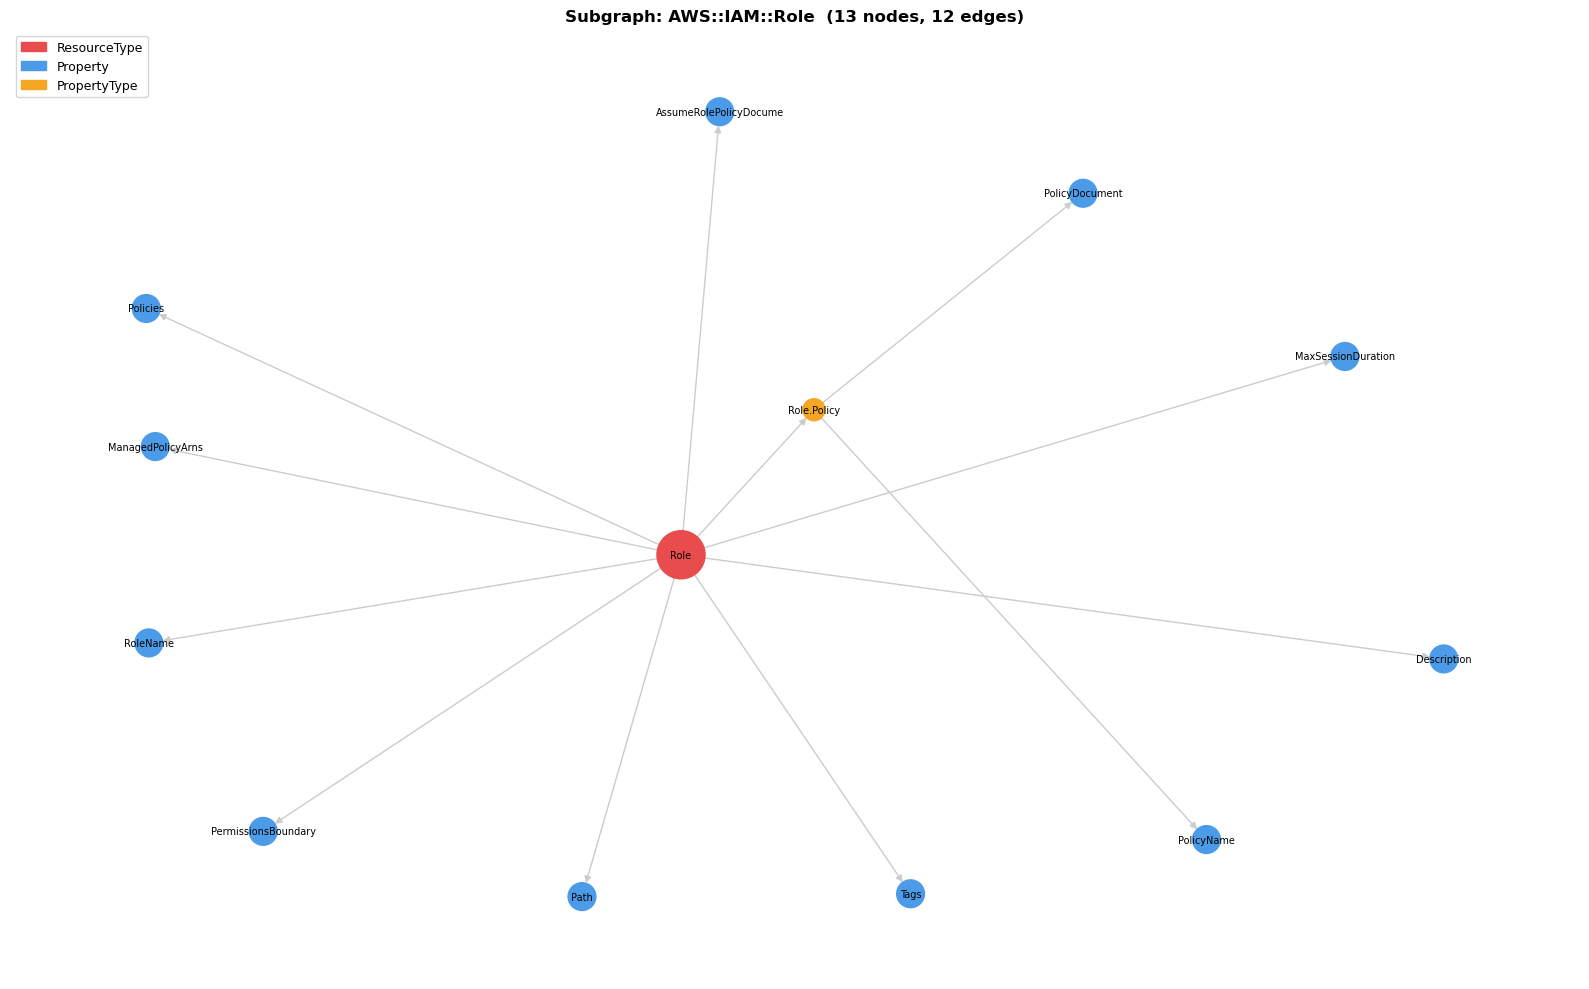

Saved → ./cfn-schema/subgraph_AWS_IAM_Role.png


In [8]:
def plot_resource_subgraph(resource: str, max_prop_nodes: int = 30, figsize=(16,10)):
    if resource not in G:
        print(f'Resource not found: {resource}')
        print('Available example resources:')
        sample = [n for n in resources if 'S3' in n or 'EC2' in n][:10]
        print('  ' + '\n  '.join(sample))
        return

    # 2-hop: resource -> props -> property-types
    nodes = {resource}
    for _, v in list(G.out_edges(resource))[:max_prop_nodes]:
        nodes.add(v)
        for _, vv in list(G.out_edges(v))[:5]:
            nodes.add(vv)

    sub = G.subgraph(nodes)

    colour_map = {
        'ResourceType':  '#E84C4C',
        'Property':      '#4C9BE8',
        'PropertyType':  '#F5A623',
    }
    node_colors = [colour_map.get(G.nodes[n].get('ntype',''), '#aaa') for n in sub.nodes()]
    node_sizes  = [1200 if G.nodes[n].get('ntype')=='ResourceType' else
                   400  if G.nodes[n].get('ntype')=='Property' else 250
                   for n in sub.nodes()]

    def short(n):
        name = G.nodes[n].get('name', n)
        return name.split('/')[-1].split('::')[-1][:22]
    labels = {n: short(n) for n in sub.nodes()}

    fig, ax = plt.subplots(figsize=figsize)
    pos = nx.spring_layout(sub, seed=42, k=1.2)
    nx.draw_networkx(sub, pos, ax=ax, labels=labels,
                     node_color=node_colors, node_size=node_sizes,
                     font_size=7, arrows=True,
                     edge_color='#cccccc', arrowsize=10)
    legend_patches = [mpatches.Patch(color=c, label=t) for t, c in colour_map.items()]
    ax.legend(handles=legend_patches, loc='upper left', fontsize=9)
    ax.set_title(f'Subgraph: {resource}  ({len(sub.nodes())} nodes, {sub.number_of_edges()} edges)',
                 fontweight='bold')
    ax.axis('off')
    safe = resource.replace('::','_')
    out = f'./cfn-schema/subgraph_{safe}.png'
    plt.tight_layout()
    plt.savefig(out, dpi=130)
    plt.show()
    print(f'Saved → {out}')

# Spot check three common resources
for res in ['AWS::S3::Bucket', 'AWS::EC2::SecurityGroup', 'AWS::IAM::Role']:
    plot_resource_subgraph(res)


## 5 · Required Properties per Resource
For RAG validation: how many required properties does each resource have?

In [9]:
rows = []
for rtype in resources:
    props = [(v, G.nodes[v]) for _, v in G.out_edges(rtype)
             if G.nodes[v].get('ntype') == 'Property']
    required = [p for p, d in props if d.get('required', False)]
    rows.append({
        'resource': rtype,
        'service': rtype.split('::')[1] if '::' in rtype else '?',
        'total_props': len(props),
        'required_props': len(required),
        'required_names': ', '.join(G.nodes[p].get('name','') for p in required[:5]),
    })

df = pd.DataFrame(rows).sort_values('required_props', ascending=False)
print('Top 15 resources with most required properties:')
display(df[['resource','total_props','required_props','required_names']].head(15)
          .reset_index(drop=True))

print(f'\nResources with 0 required properties: {(df.required_props==0).sum()}')
print(f'Resources with ≥5 required properties: {(df.required_props>=5).sum()}')
df.to_csv('./cfn-schema/cfn_required_props.csv', index=False)
print('Saved → ./cfn-schema/cfn_required_props.csv')


Top 15 resources with most required properties:


,resource,total_props,required_props,required_names
0,AWS::KafkaConnect::Connector,14,9,"KafkaCluster, KafkaConnectVersion, ConnectorCo..."
1,AWS::LicenseManager::License,12,9,"ProductSKU, ConsumptionConfiguration, Validity..."
2,AWS::MediaLive::CloudWatchAlarmTemplate,13,9,"TargetResourceType, ComparisonOperator, TreatM..."
3,AWS::CUR::ReportDefinition,13,9,"Compression, RefreshClosedReports, ReportVersi..."
4,AWS::ServiceCatalog::StackSetConstraint,9,8,"Description, StackInstanceControl, PortfolioId..."
5,AWS::EMR::Studio,17,8,"WorkspaceSecurityGroupId, DefaultS3Location, S..."
6,AWS::EVS::Environment,14,8,"LicenseInfo, SiteId, ConnectivityInfo, VpcId, ..."
7,AWS::DataZone::SubscriptionTarget,9,7,"Type, EnvironmentIdentifier, SubscriptionTarge..."
8,AWS::OpsWorks::Layer,19,7,"AutoAssignElasticIps, AutoAssignPublicIps, Ena..."
9,AWS::Budgets::BudgetsAction,9,7,"ExecutionRoleArn, ActionType, NotificationType..."



Resources with 0 required properties: 240
Resources with ≥5 required properties: 74
Saved → ./cfn-schema/cfn_required_props.csv


## 6 · Graph Integrity Checks

In [10]:
issues = []

# 1. Orphan property nodes (not reachable from any resource)
all_prop_nodes = {n for n, d in G.nodes(data=True) if d.get('ntype')=='Property'}
prop_parents   = {v for _, v, d in G.edges(data=True) if d.get('etype')=='HAS_PROPERTY'}
orphan_props   = all_prop_nodes - prop_parents
issues.append(('Orphan Property nodes', len(orphan_props)))

# 2. Resources with no properties at all
empty_resources = [r for r in resources if G.out_degree(r) == 0]
issues.append(('Resources with 0 edges', len(empty_resources)))
if empty_resources:
    print('  Examples:', empty_resources[:5])

# 3. Self-loops
self_loops = list(nx.selfloop_edges(G))
issues.append(('Self-loop edges', len(self_loops)))

# 4. Duplicate node IDs (sanity — should be 0 in networkx)
issues.append(('Total nodes', G.number_of_nodes()))
issues.append(('Total edges', G.number_of_edges()))

# 5. Weakly connected components
wcc = list(nx.weakly_connected_components(G))
issues.append(('Weakly connected components', len(wcc)))
largest = max(wcc, key=len)
issues.append(('Largest component size', len(largest)))

print('=== Integrity Report ===')
for label, val in issues:
    flag = ' ⚠️' if label.startswith('Orphan') and val > 0 else ''
    print(f'  {label:<40} {val:>7,}{flag}')

# Expected: components > 1 is OK (isolated resource types are valid)
# Orphan property nodes should be 0


  Examples: ['AWS::ApplicationSignals::Discovery', 'AWS::CloudFormation::WaitConditionHandle', 'AWS::DevOpsGuru::LogAnomalyDetectionIntegration']
=== Integrity Report ===
  Orphan Property nodes                          0
  Resources with 0 edges                         3
  Self-loop edges                                0
  Total nodes                               46,820
  Total edges                               45,251
  Weakly connected components                1,569
  Largest component size                     2,479


## 7 · RAG Retrieval Smoke Test
Simulate how the graph would answer property-lookup queries — the core use case for IaC generation.

In [11]:
def query_graph(resource_type: str, property_hint: str = None):
    """
    Return structured context about a resource type:
    required props, all prop names + types, and nested property types.
    Mimics what a GraphRAG retriever would return to an LLM.
    """
    if resource_type not in G:
        return f'ERROR: {resource_type} not in graph'

    out = [f'Resource: {resource_type}']

    props, ptypes = [], []
    for _, v in G.out_edges(resource_type):
        nd = G.nodes[v]
        if nd.get('ntype') == 'Property':
            props.append(nd)
        elif nd.get('ntype') == 'PropertyType':
            ptypes.append(nd)

    required = [p for p in props if p.get('required')]
    optional = [p for p in props if not p.get('required')]

    out.append(f'  Required ({len(required)}): ' +
               ', '.join(p.get('name','?') for p in required))
    out.append(f'  Optional ({len(optional)} total, showing first 10):')
    for p in optional[:10]:
        ptype = p.get('primitive_type') or p.get('type') or '?'
        out.append(f'    - {p.get("name","?"):<35} [{ptype}]')
    if ptypes:
        out.append(f'  Nested property types ({len(ptypes)}): ' +
                   ', '.join(p.get('name','?').split('.')[-1] for p in ptypes[:6]))

    if property_hint:
        # Search for matching property by name
        matches = [p for p in props
                   if property_hint.lower() in p.get('name','').lower()]
        if matches:
            out.append(f'\n  Property search "{property_hint}":')
            for m in matches:
                out.append(f'    ✓ {m.get("name")} | required={m.get("required")} '
                           f'| type={m.get("primitive_type") or m.get("type")} '
                           f'| update={m.get("update_type")}')

    return '\n'.join(out)


# --- Run smoke tests ---
test_cases = [
    ('AWS::S3::Bucket',                 'BucketName'),
    ('AWS::EC2::SecurityGroup',         'GroupDescription'),
    ('AWS::IAM::Role',                  'AssumeRolePolicyDocument'),
    ('AWS::RDS::DBInstance',            'MasterUserPassword'),
    ('AWS::Lambda::Function',           'Handler'),
    ('AWS::DynamoDB::Table',            'BillingMode'),
    ('AWS::ECS::TaskDefinition',        'ContainerDefinitions'),
    ('AWS::CloudFormation::Stack',      'TemplateURL'),
]

for resource, hint in test_cases:
    print('─' * 70)
    print(query_graph(resource, hint))
print('─' * 70)


──────────────────────────────────────────────────────────────────────
Resource: AWS::S3::Bucket
  Required (0): 
  Optional (25 total, showing first 10):
    - BucketNamespace                     [String]
    - InventoryConfigurations             [List]
    - BucketNamePrefix                    [String]
    - WebsiteConfiguration                [WebsiteConfiguration]
    - AccessControl                       [String]
    - MetadataTableConfiguration          [MetadataTableConfiguration]
    - AnalyticsConfigurations             [List]
    - AbacStatus                          [String]
    - AccelerateConfiguration             [AccelerateConfiguration]
    - PublicAccessBlockConfiguration      [PublicAccessBlockConfiguration]
  Nested property types (67): AbortIncompleteMultipartUpload, AccelerateConfiguration, AccessControlTranslation, AnalyticsConfiguration, BlockedEncryptionTypes, BucketEncryption

  Property search "BucketName":
    ✓ BucketNamespace | required=False | type=String 

## 8 · Interactive Explorer (requires ipywidgets)
Type any AWS resource type to inspect its graph context live.

In [12]:
if HAS_WIDGETS:
    text  = widgets.Combobox(
        value='AWS::S3::Bucket',
        options=sorted(resources),
        description='Resource:',
        layout=widgets.Layout(width='420px'),
        ensure_option=False,
    )
    hint  = widgets.Text(value='', description='Prop filter:', placeholder='e.g. Name')
    out   = widgets.Output()

    def on_change(_):
        with out:
            out.clear_output()
            print(query_graph(text.value, hint.value or None))

    text.observe(on_change, names='value')
    hint.observe(on_change, names='value')
    on_change(None)
    wdisplay(widgets.VBox([widgets.HBox([text, hint]), out]))
else:
    # Fallback — just dump a few more examples
    for res in random.sample(resources, min(5, len(resources))):
        print('─' * 60)
        print(query_graph(res))


## 9 · Export Summary

In [14]:
rows = []
for rtype in resources:
    neighbours = list(G.out_edges(rtype, data=True))
    prop_nodes  = [v for _, v, d in neighbours if G.nodes[v].get('ntype')=='Property']
    ptype_nodes = [v for _, v, d in neighbours if G.nodes[v].get('ntype')=='PropertyType']
    req = [G.nodes[v].get('name','') for v in prop_nodes if G.nodes[v].get('required')]
    rows.append({
        'resource_type': rtype,
        'service': rtype.split('::')[1] if '::' in rtype else '?',
        'n_properties': len(prop_nodes),
        'n_property_types': len(ptype_nodes),
        'n_required': len(req),
        'required_properties': '|'.join(req),
        'out_degree': G.out_degree(rtype),
        'in_degree': G.in_degree(rtype),
    })

summary_df = pd.DataFrame(rows).sort_values('resource_type')
summary_df.to_csv('./cfn-schema/cfn_graph_summary.csv', index=False)
print(f'Exported {len(summary_df):,} resources → ./cfn-schema/cfn_graph_summary.csv')
display(summary_df.groupby('service').agg(
    resources=('resource_type','count'),
    avg_props=('n_properties','mean'),
    avg_required=('n_required','mean')
).round(1).sort_values('resources', ascending=False).head(20))


Exported 1,568 resources → ./cfn-schema/cfn_graph_summary.csv


,resources,avg_props,avg_required
service,,,
EC2,113,6.2,1.6
Connect,34,6.4,2.4
SageMaker,34,8.6,2.4
IoT,30,5.5,1.2
Glue,25,6.5,1.8
ApiGateway,22,6.2,1.4
SES,21,3.7,1.2
CloudFront,20,2.8,1.6
Pinpoint,19,6.4,1.7
